In [4]:
# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [5]:
# Đặt style cho matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# 2. Đọc dữ liệu
df = pd.read_csv('dataset_cleaned_ready.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (1000, 19)
   Image_id  material_image_id  style_tags_boho  style_tags_industrial  \
0         1                  1              0.0                    1.0   
1         2                  2              0.0                    0.0   
2         3                  3              0.0                    1.0   
3         4                  4              1.0                    0.0   
4         5                  5              0.0                    0.0   

   style_tags_minimalist  style_tags_scandinavian  material_type_fabric  \
0                    0.0                      0.0                   0.0   
1                    1.0                      0.0                   0.0   
2                    0.0                      0.0                   0.0   
3                    0.0                      0.0                   1.0   
4                    1.0                      0.0                   0.0   

   material_type_glass  material_type_leather  material_type_marble  \
0              

C:\Users\HP\AppData\Local\Temp\ipykernel_24116\3941019509.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=style_counts.values, y=style_counts.index, palette='viridis')


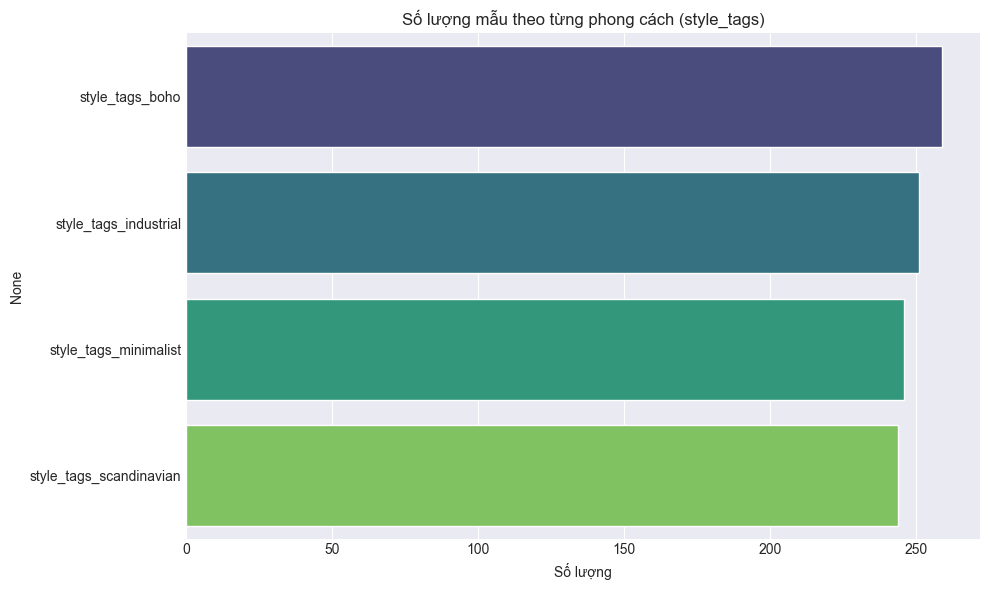

In [7]:
# Lấy các cột style_tags_*
style_cols = [col for col in df.columns if col.startswith('style_tags_')]
style_counts = df[style_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=style_counts.values, y=style_counts.index, palette='viridis')
plt.title('Số lượng mẫu theo từng phong cách (style_tags)')
plt.xlabel('Số lượng')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24116\3510848637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=material_counts.values, y=material_counts.index, palette='plasma')


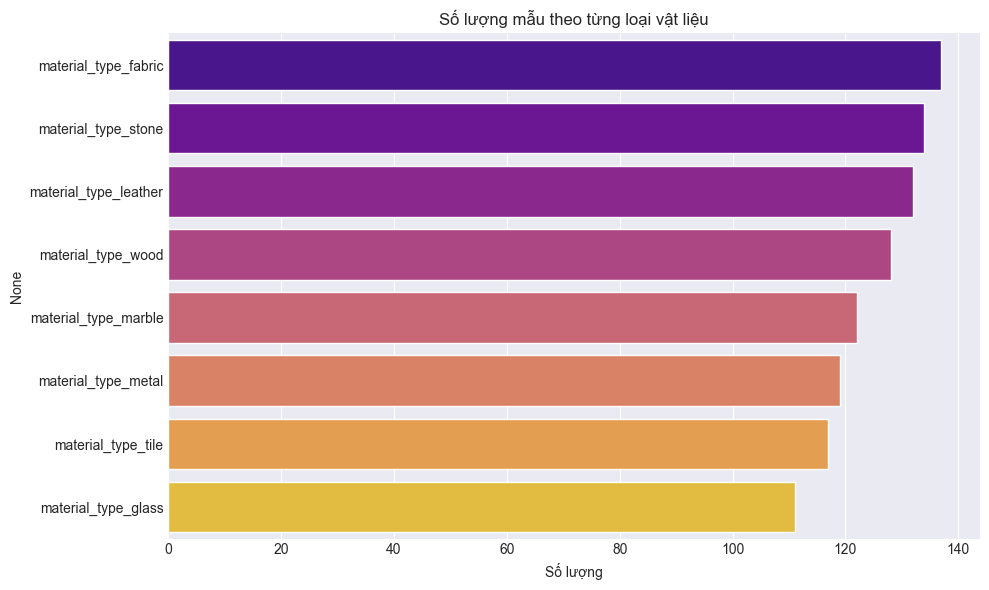

In [8]:
material_cols = [col for col in df.columns if col.startswith('material_type_')]
material_counts = df[material_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=material_counts.values, y=material_counts.index, palette='plasma')
plt.title('Số lượng mẫu theo từng loại vật liệu')
plt.xlabel('Số lượng')
plt.tight_layout()
plt.show()

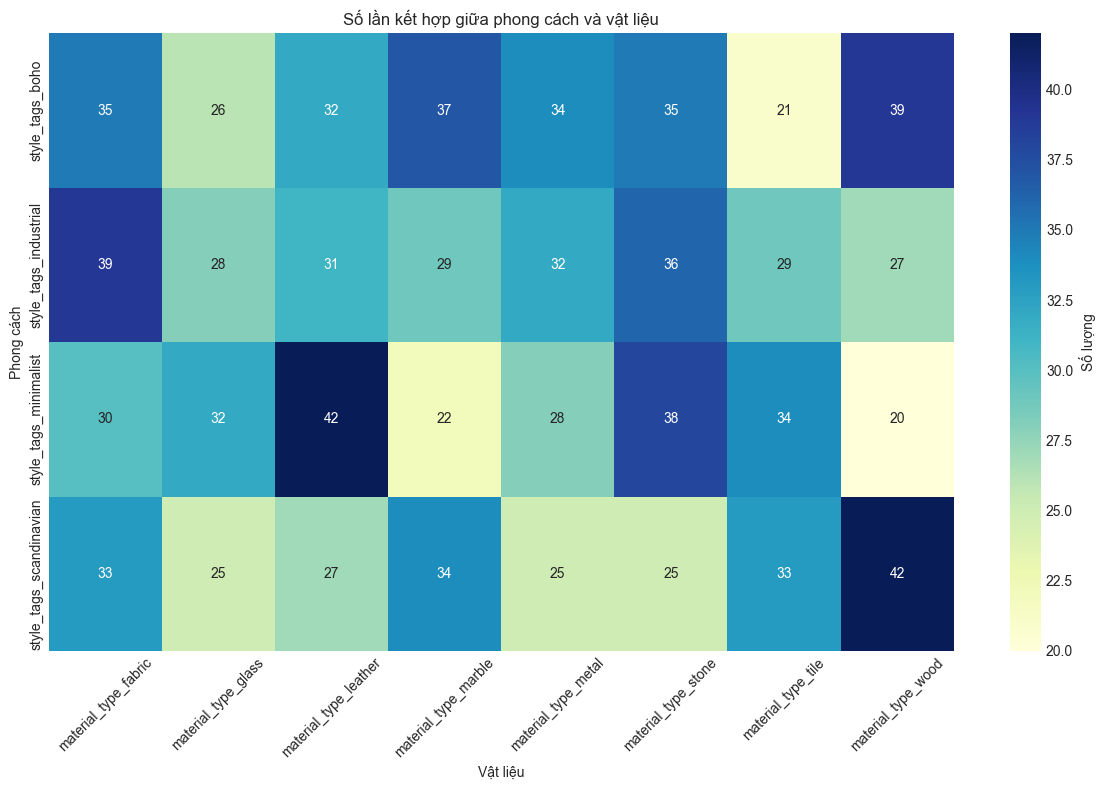

In [9]:
# Tạo ma trận đồng xuất hiện
co_occur = pd.DataFrame(0, index=style_cols, columns=material_cols)
for s in style_cols:
    for m in material_cols:
        co_occur.loc[s, m] = ((df[s] == 1) & (df[m] == 1)).sum()

plt.figure(figsize=(12, 8))
sns.heatmap(co_occur, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Số lượng'})
plt.title('Số lần kết hợp giữa phong cách và vật liệu')
plt.xlabel('Vật liệu')
plt.ylabel('Phong cách')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

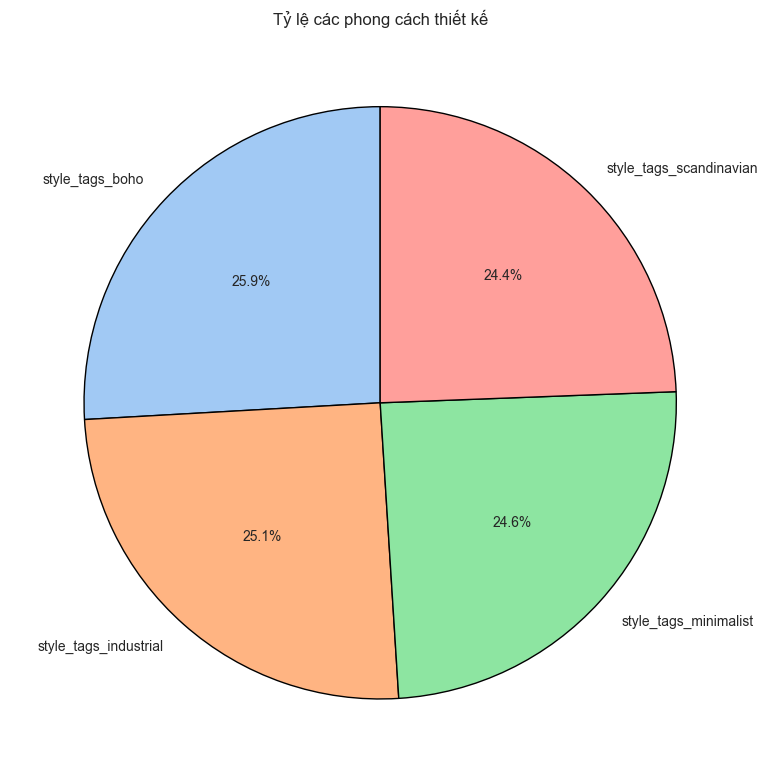

In [10]:
plt.figure(figsize=(8,8))
plt.pie(style_counts, labels=style_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ các phong cách thiết kế')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24116\3106421510.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.values, y=color_counts.index, palette='rocket')


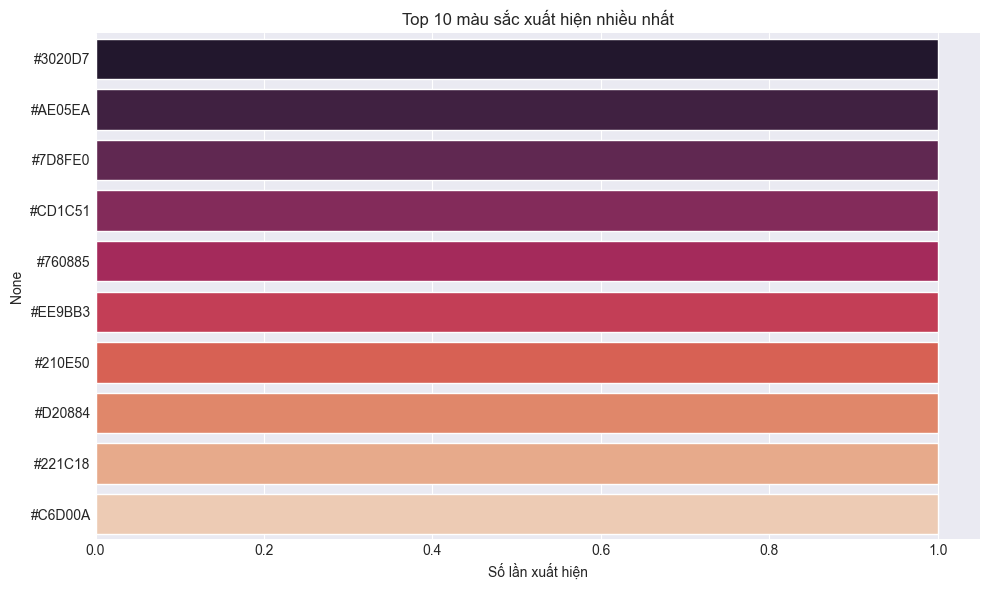

In [11]:
# Gộp tất cả màu sắc từ 3 cột
all_colors = pd.concat([df['color1'], df['color2'], df['color3']]).dropna()
color_counts = all_colors.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=color_counts.values, y=color_counts.index, palette='rocket')
plt.title('Top 10 màu sắc xuất hiện nhiều nhất')
plt.xlabel('Số lần xuất hiện')
plt.tight_layout()
plt.show()

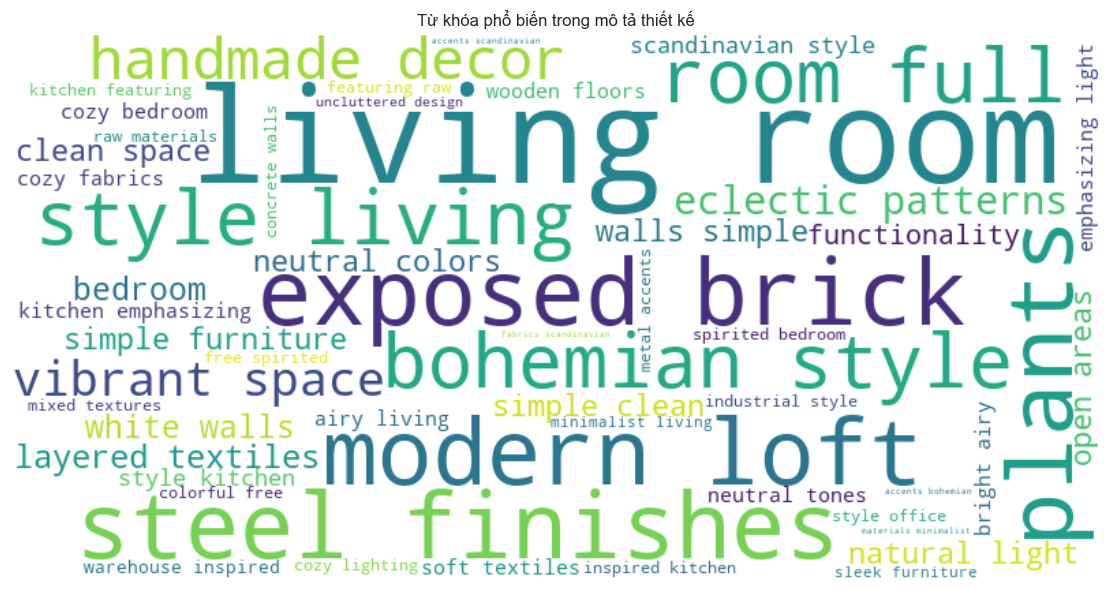

In [12]:
# Kết hợp tất cả description
text = ' '.join(df['clean_design_description'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Từ khóa phổ biến trong mô tả thiết kế')
plt.tight_layout()
plt.show()

In [13]:
# Chọn 3 style phổ biến nhất
top3_styles = style_counts.head(3).index.tolist()
# Tạo một cột tổng hợp: style chính (cái có giá trị 1)
df['main_style'] = df[top3_styles].idxmax(axis=1)

# Chọn 3 material phổ biến nhất
top3_materials = material_counts.head(3).index.tolist()
df['main_material'] = df[top3_materials].idxmax(axis=1)

fig = px.scatter_3d(df, x='color1', y='color2', z='color3',
                    color='main_style', symbol='main_material',
                    title='Phân bố không gian màu theo style và material',
                    labels={'color1': 'Màu 1', 'color2': 'Màu 2', 'color3': 'Màu 3'})
fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_24116\3047402667.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='main_style', y='desc_len', palette='Set2')


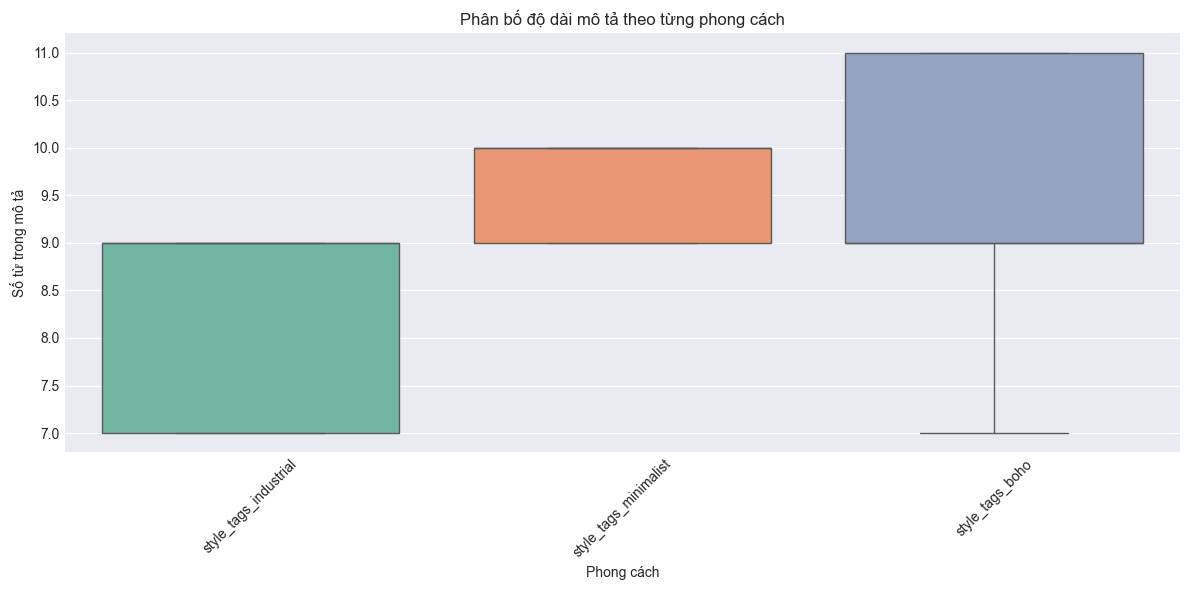

In [14]:
df['desc_len'] = df['clean_design_description'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='main_style', y='desc_len', palette='Set2')
plt.title('Phân bố độ dài mô tả theo từng phong cách')
plt.xlabel('Phong cách')
plt.ylabel('Số từ trong mô tả')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()